In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DATA_DIR = "LOBSTER_SampleFile_AAPL_2012-06-21_10"
MSG_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_message_10.csv"
OB_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"
N_LEVELS = 10
TICK = 0.01  # NASDAQ minimum tick size for stocks > $1

EVENT_TYPE_LABELS = {
    1: "New limit order",
    2: "Partial cancel",
    3: "Full delete",
    4: "Execution (visible)",
    5: "Execution (hidden)",
    7: "Trading halt",
}

In [2]:
msg_cols = ["time", "event_type", "order_id", "size", "price", "direction"]

ob_cols = []
for lvl in range(1, N_LEVELS + 1):
    ob_cols += [f"ask_price_{lvl}", f"ask_size_{lvl}", f"bid_price_{lvl}", f"bid_size_{lvl}"]

df_msg = pd.read_csv(MSG_FILE, names=msg_cols)
df_ob = pd.read_csv(OB_FILE, names=ob_cols)

assert len(df_msg) == len(df_ob), "message and orderbook files must be row-aligned"

# Rescale fixed-point prices (x10,000) to dollars
df_msg["price"] = df_msg["price"] / 10_000
price_cols = [c for c in df_ob.columns if "price" in c]
df_ob[price_cols] = df_ob[price_cols] / 10_000

# Human-readable time-of-day, still keeping the original float seconds for arithmetic
df_msg["time_sec"] = df_msg["time"]
df_msg["time"] = pd.to_datetime(df_msg["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
df_msg["event_label"] = df_msg["event_type"].map(EVENT_TYPE_LABELS)

# One combined frame: each row = an event + the resulting book state
df = pd.concat([df_msg, df_ob], axis=1)

print(f"{len(df):,} events from {df_msg['time'].min().time()} to {df_msg['time'].max().time()}")
df.head(20)

400,391 events from 09:30:00.004241 to 15:59:59.913117


,time,event_type,order_id,size,price,direction,time_sec,event_label,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,bid_price_3,bid_size_3,ask_price_4,ask_size_4,bid_price_4,bid_size_4,ask_price_5,ask_size_5,bid_price_5,bid_size_5,ask_price_6,ask_size_6,bid_price_6,bid_size_6,ask_price_7,ask_size_7,bid_price_7,bid_size_7,ask_price_8,ask_size_8,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,2012-06-21 09:30:00.004241228,1,16113575,18,585.33,1,34200.004241,New limit order,585.94,200,585.33,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300,587.65,1160,584.38,200,587.90,500,584.27,300
1,2012-06-21 09:30:00.004260540,1,16113584,18,585.32,1,34200.004261,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300,587.90,500,584.38,200
2,2012-06-21 09:30:00.004447460,1,16113594,18,585.31,1,34200.004447,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.31,18,586.89,300,585.30,150,586.95,50,585.10,5,587.00,100,585.01,89,587.10,10,584.97,5,587.39,100,584.93,300,587.65,1160,584.65,300,587.90,500,584.53,300
3,2012-06-21 09:30:00.025551796,1,16120456,18,585.91,-1,34200.025552,New limit order,585.91,18,585.33,18,585.94,200,585.32,18,585.98,200,585.31,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300
4,2012-06-21 09:30:00.025579453,1,16120480,18,585.92,-1,34200.025580,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.94,200,585.31,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300
5,2012-06-21 09:30:00.025613070,1,16120503,18,585.93,-1,34200.025613,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.93,18,585.31,18,585.94,200,585.30,150,585.98,200,585.10,5,586.10,200,585.01,89,586.89,300,584.97,5,586.95,50,584.93,300,587.00,100,584.65,300,587.10,10,584.53,300
6,2012-06-21 09:30:00.050240993,1,16127688,100,585.00,1,34200.050241,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.93,18,585.31,18,585.94,200,585.30,150,585.98,200,585.10,5,586.10,200,585.01,89,586.89,300,585.00,100,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300
7,2012-06-21 09:30:00.201518059,1,16166035,100,585.93,-1,34200.201518,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.93,118,585.31,18,585.94,200,585.30,150,585.98,200,585.10,5,586.10,200,585.01,89,586.89,300,585.00,100,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300
8,2012-06-21 09:30:00.201735973,3,16113594,18,585.31,1,34200.201736,Full delete,585.91,18,585.33,18,585.92,18,585.32,18,585.93,118,585.30,150,585.94,200,585.10,5,585.98,200,585.01,89,586.10,200,585.00,100,586.89,300,584.97,5,586.95,50,584.93,300,587.00,100,584.65,300,587.10,10,584.53,300
9,2012-06-21 09:30:00.201742411,3,16113584,18,585.32,1,34200.201742,Full delete,585.91,18,585.33,18,585.92,18,585.30,150,585.93,118,585.10,5,585.94,200,585.01,89,585.98,200,585.00,100,586.10,200,584.97,5,586.89,300,584.93,300,586.95,50,584.65,300,587.00,100,584.53,300,587.10,10,584.38,200


count    400391.000000
mean        583.152849
std           2.834982
min         577.480000
25%         581.245000
50%         583.235000
75%         585.660000
max         588.185000
Name: mid_price, dtype: float64

count    400391.000000
mean         15.348894
std           7.415759
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          92.000000
Name: spread_ticks, dtype: float64


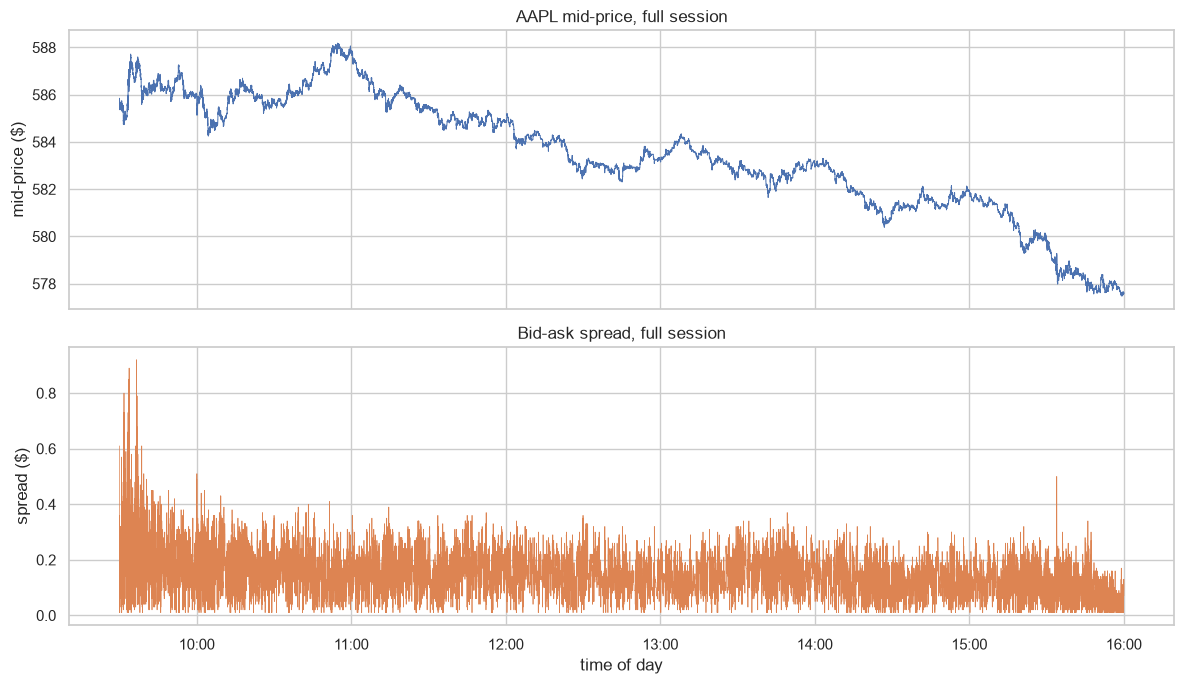

In [3]:
df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2
df["spread"] = df["ask_price_1"] - df["bid_price_1"]
df["spread_ticks"] = (df["spread"] / TICK).round().astype(int)

print(df["mid_price"].describe())
print()
print(df["spread_ticks"].describe())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df["time"], df["mid_price"], color="#4C72B0", linewidth=0.7)
axes[0].set_ylabel("mid-price ($)")
axes[0].set_title("AAPL mid-price, full session")

axes[1].plot(df["time"], df["spread"], color="#DD8452", linewidth=0.5)
axes[1].set_ylabel("spread ($)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_title("Bid-ask spread, full session")

plt.tight_layout()
plt.show()

In [4]:
fundamental_df = df[['time', 'mid_price']].copy()
fundamental_df = fundamental_df.drop_duplicates(subset=['time'], keep='last')
fundamental_df.set_index('time', inplace=True)

# 2. 1초(1S) 단위로 Resample 후, 거래가 없는 초는 이전 가격으로 채움 (Forward Fill)
# ABIDES 오라클은 빈 시간(NaN)이 없는 연속적인 시계열을 요구합니다.
fundamental_series = fundamental_df['mid_price'].resample('1s').ffill()

# 3. 장 시작 직전의 결측치가 있다면 뒤의 값으로 채움 (Backward Fill)
fundamental_series = fundamental_series.bfill()

# ABIDES에서 사용할 수 있도록 포맷 확인
print("=== ABIDES Fundamental Price Series ===")
print(f"Start Time: {fundamental_series.index.min()}")
print(f"End Time:   {fundamental_series.index.max()}")
print(f"Data Points: {len(fundamental_series):,}")
print(fundamental_series.head())

=== ABIDES Fundamental Price Series ===
Start Time: 2012-06-21 09:30:00
End Time:   2012-06-21 15:59:59
Data Points: 23,400
time
2012-06-21 09:30:00    585.805
2012-06-21 09:30:01    585.805
2012-06-21 09:30:02    585.620
2012-06-21 09:30:03    585.575
2012-06-21 09:30:04    585.580
Freq: s, Name: mid_price, dtype: float64


In [35]:
import numpy as np
import pandas as pd
from abides_core.abides import run as abides_run
from abides_core.generators import ConstantTimeGenerator
from abides_markets.agents.market_makers.adaptive_market_maker_agent import AdaptiveMarketMakerAgent
from abides_markets.agents.value_agent import ValueAgent
from abides_markets.agents.noise_agent import NoiseAgent
from abides_markets.oracles.oracle import Oracle
from abides_markets.agents.exchange_agent import ExchangeAgent
from abides_markets.agents.trading_agent import TradingAgent

# 1. 견고한 Historical Oracle (에러 방지용 float 변환 적용)
class HistoricalOracle(Oracle):
    def __init__(self, fundamental_series):
        self.fundamental_series = fundamental_series
        
    def get_daily_open_price(self, symbol, mkt_open, date=None):
        return float(self.fundamental_series.iloc[0])
        
    def observe_price(self, symbol, current_time, random_state=None, sigma_n=0):
        time_key = current_time.floor('S') # 정확히 1초 단위로 맞춤
        try:
            return float(self.fundamental_series.loc[time_key])
        except KeyError:
            if time_key < self.fundamental_series.index[0]:
                return float(self.fundamental_series.iloc[0])
            else:
                return float(self.fundamental_series.iloc[-1])

# 2. Config 및 Agent 세팅
def build_aapl_config(fundamental_series):
    agents = []
    oracle = HistoricalOracle(fundamental_series)
    
    # [A] Market Maker
    agents.append(AdaptiveMarketMakerAgent(
        id=0, name="ADAPTIVE_MM", type="MarketMakerAgent", symbol="AAPL", 
        starting_cash=100_000_000, window_size=10, pov=0.025, min_order_size=100
    ))
    
    # [B] Value Agents
    for i in range(1, 51):
        agents.append(ValueAgent(
            id=i, name=f"VALUE_{i}", type="ValueAgent", symbol="AAPL", 
            starting_cash=1_000_000
        ))
        
    # [C] Noise Agents (Timedelta 객체 주입으로 버그 픽스)
    for i in range(51, 551):
        agents.append(NoiseAgent(
            id=i, name=f"NOISE_{i}", type="NoiseAgent", symbol="AAPL", 
            starting_cash=100_000, wakeup_time=ConstantTimeGenerator(step_duration=pd.Timedelta('10s'))
        ))
        
    return agents, oracle

# 3. TWAP 에이전트 클래스 정의 (snake_case 완벽 적용)
class TWAPAgent(TradingAgent):
    def __init__(self, id, name, symbol, starting_cash, total_shares, start_time, end_time, num_slices, direction='BID', **kwargs):
        super().__init__(id, name, type="ExecutionAgent", starting_cash=starting_cash, **kwargs)
        self.symbol = symbol
        self.total_shares = total_shares
        self.direction = direction
        self.start_time = start_time
        self.end_time = end_time
        self.num_slices = num_slices
        self.slice_size = self.total_shares // self.num_slices
        self.slice_interval = (self.end_time - self.start_time) / self.num_slices
        self.current_slice = 0
        
    def kernel_starting(self, start_time):
        super().kernel_starting(start_time)
        self.set_wakeup(self.start_time)  # 알람 설정 (snake_case)
        
    def wakeup(self, current_time):
        super().wakeup(current_time)
        if self.current_slice < self.num_slices:
            print(f"[{current_time}] 🤖 TWAP Agent: {self.slice_size}주 {self.direction} 시장가 주문 발송!")
            # 시장가 주문 발송 (snake_case)
            self.place_market_order(self.symbol, quantity=self.slice_size, side=self.direction)
            self.current_slice += 1
            
            next_wakeup = self.start_time + (self.current_slice * self.slice_interval)
            if next_wakeup <= self.end_time:
                self.set_wakeup(next_wakeup)

# ==========================================
# 4. 🚀 최종 시뮬레이션 부팅!
# ==========================================
agents, oracle = build_aapl_config(fundamental_series)
mkt_open = fundamental_series.index.min()
mkt_close = fundamental_series.index.max()

# 거래소 추가
exchange = ExchangeAgent(
    id=10000, name="NASDAQ", type="ExchangeAgent",
    mkt_open=mkt_open, mkt_close=mkt_close, symbols=["AAPL"]
)
agents.append(exchange)

# TWAP Agent 투입 (10시부터 1시간 동안)
twap_start = mkt_open + pd.Timedelta(minutes=30)
twap_agent = TWAPAgent(
    id=9999, name="TWAP_BUYER", symbol="AAPL", starting_cash=10_000_000,
    total_shares=10_000, start_time=twap_start, end_time=twap_start + pd.Timedelta(hours=1), num_slices=10, direction="BID"
)
agents.append(twap_agent)

# ✅ 핵심 픽스: 커널 시작 시간을 그날의 "자정(00:00:00)"으로 맞춤
midnight = mkt_open.replace(hour=0, minute=0, second=0)

config = {
    "start_time": midnight,  
    "stop_time": mkt_close,
    "agents": agents,
    "custom_properties": {"oracle": oracle}, 
    "random_state_kernel": np.random.RandomState(seed=42),
    "stdout_log_level": "INFO"
}

print("🔥 ABIDES 시뮬레이션 부팅 시작...")
end_state = abides_run(config)

print("✅ 시뮬레이션 종료! 10번의 TWAP 체결이 무사히 끝났습니다.")

[13000] INFO abides Simulation Start Time: 2026-09-03 13:17:47.175856


🔥 ABIDES 시뮬레이션 부팅 시작...


IndexError: list index out of range

In [39]:
import numpy as np
import pandas as pd
from abides_core import abides
from abides_core.generators import ConstantTimeGenerator
from abides_markets.agents.exchange_agent import ExchangeAgent
from abides_markets.agents.market_makers.adaptive_market_maker_agent import AdaptiveMarketMakerAgent
from abides_markets.agents.value_agent import ValueAgent
from abides_markets.agents.noise_agent import NoiseAgent
from abides_markets.agents.trading_agent import TradingAgent
from abides_markets.oracles.oracle import Oracle

# 1. Clean Historical Oracle
class HistoricalOracle(Oracle):
    def __init__(self, fundamental_series):
        self.fundamental_series = fundamental_series
        
    def get_daily_open_price(self, symbol, mkt_open, date=None):
        return float(self.fundamental_series.iloc[0])
        
    def observe_price(self, symbol, current_time, random_state=None, sigma_n=0):
        time_key = current_time.floor('S')
        try:
            return float(self.fundamental_series.loc[time_key])
        except KeyError:
            if time_key < self.fundamental_series.index[0]:
                return float(self.fundamental_series.iloc[0])
            else:
                return float(self.fundamental_series.iloc[-1])

# 2. Robust TWAP Execution Agent
# 2. Robust TWAP Execution Agent (Seed-safe initialization)
class TWAPAgent(TradingAgent):
    def __init__(self, id, name, symbol, starting_cash, total_shares, start_time, end_time, num_slices, direction='BID', **kwargs):
        super().__init__(id, name, type="ExecutionAgent", starting_cash=starting_cash, **kwargs)
        self.symbol = symbol
        self.total_shares = total_shares
        self.direction = direction
        self.target_start_time = start_time  # Actual trading start time (10:00 AM)
        self.end_time = end_time
        self.num_slices = num_slices
        self.slice_size = self.total_shares // self.num_slices
        self.slice_interval = (self.end_time - self.target_start_time) / self.num_slices
        self.current_slice = 0
        
    def kernel_starting(self, start_time):
        super().kernel_starting(start_time)
        # Wake up immediately at market open (or kernel start) to populate the event queue
        self.set_wakeup(start_time)
        
    def wakeup(self, current_time):
        super().wakeup(current_time)
        
        # If we have reached or passed the target start time, execute slices
        if current_time >= self.target_start_time and self.current_slice < self.num_slices:
            print(f"[{current_time}] 🤖 TWAP Agent: Executing {self.slice_size} shares {self.direction} market order.")
            self.place_market_order(self.symbol, quantity=self.slice_size, side=self.direction)
            self.current_slice += 1
            
            # Schedule next slice
            next_wakeup = self.target_start_time + (self.current_slice * self.slice_interval)
            if next_wakeup <= self.end_time:
                self.set_wakeup(next_wakeup)
        elif current_time < self.target_start_time:
            # If before trading time, check again right at target start time
            self.set_wakeup(self.target_start_time)

agents = []

# Exchange Agent (Must be index 0 for L1/L2 log parsing)
agents.append(ExchangeAgent(
    id=0,
    name="NASDAQ",
    type="ExchangeAgent",
    mkt_open=mkt_open,
    mkt_close=mkt_close,
    symbols=["AAPL"],
    book_logging=True,
    log_orders=True
))

# Adaptive Market Maker
agents.append(AdaptiveMarketMakerAgent(
    id=1, name="ADAPTIVE_MM", type="MarketMakerAgent", symbol="AAPL",
    starting_cash=100_000_000, window_size=10, pov=0.025, min_order_size=150
))

# Value Agents
for i in range(2, 52):
    agents.append(ValueAgent(
        id=i, name=f"VALUE_{i}", type="ValueAgent", symbol="AAPL",
        starting_cash=1_000_000
    ))

# Noise Agents (Pre-seeded with startup wakeups to populate event queue)
for i in range(52, 352):
    agents.append(NoiseAgent(
        id=i, name=f"NOISE_{i}", type="NoiseAgent", symbol="AAPL",
        starting_cash=100_000, wakeup_time=ConstantTimeGenerator(step_duration=pd.Timedelta('30s'))
    ))

# TWAP Execution Agent
twap_start = mkt_open + pd.Timedelta(minutes=30)
twap_agent = TWAPAgent(
    id=9999, name="TWAP_BUYER", symbol="AAPL", starting_cash=10_000_000,
    total_shares=10_000, start_time=twap_start, end_time=twap_start + pd.Timedelta(hours=1),
    num_slices=10, direction="BID"
)
agents.append(twap_agent)

# 4. Kernel Configuration Dictionary
config = {
    "start_time": mkt_open,
    "stop_time": mkt_close,
    "agents": agents,
    "agent_latency_model": None,
    "default_computation_delay": 0,
    "custom_properties": {"oracle": oracle},
    "random_state_kernel": np.random.RandomState(seed=42),
    "stdout_log_level": "INFO"
}

print("🔥 Launching ABIDES Simulation...")
end_state = abides.run(config)
print("✅ Simulation complete! Check end_state for execution logs.")

[13000] INFO abides Simulation Start Time: 2026-09-03 13:19:25.741349


🔥 Launching ABIDES Simulation...


IndexError: list index out of range

In [41]:
import numpy as np
import pandas as pd
from abides_core import abides
from abides_markets.agents.exchange_agent import ExchangeAgent
from abides_markets.agents.market_makers.adaptive_market_maker_agent import AdaptiveMarketMakerAgent
from abides_markets.agents.trading_agent import TradingAgent
from abides_markets.oracles.oracle import Oracle

# 1. Clean Historical Oracle
class HistoricalOracle(Oracle):
    def __init__(self, fundamental_series):
        self.fundamental_series = fundamental_series
        
    def get_daily_open_price(self, symbol, mkt_open, date=None):
        return float(self.fundamental_series.iloc[0])
        
    def observe_price(self, symbol, current_time, random_state=None, sigma_n=0):
        time_key = current_time.floor('S')
        try:
            return float(self.fundamental_series.loc[time_key])
        except KeyError:
            if time_key < self.fundamental_series.index[0]:
                return float(self.fundamental_series.iloc[0])
            else:
                return float(self.fundamental_series.iloc[-1])

# 2. Robust TWAP Execution Agent (Populates event queue immediately)
# 2. Robust TWAP Execution Agent (CamelCase lifecycle hooks)
class TWAPAgent(TradingAgent):
    def __init__(self, id, name, symbol, starting_cash, total_shares, start_time, end_time, num_slices, direction='BID', **kwargs):
        super().__init__(id, name, type="ExecutionAgent", starting_cash=starting_cash, **kwargs)
        self.symbol = symbol
        self.total_shares = total_shares
        self.direction = direction
        self.target_start_time = start_time
        self.end_time = end_time
        self.num_slices = num_slices
        self.slice_size = self.total_shares // self.num_slices
        self.slice_interval = (self.end_time - self.target_start_time) / self.num_slices
        self.current_slice = 0
        
    def kernelStarting(self, start_time):
        super().kernelStarting(start_time)
        # Seed the event queue immediately at start time using CamelCase
        self.setWakeup(start_time)
        
    def wakeup(self, current_time):
        super().wakeup(current_time)
        
        if current_time >= self.target_start_time and self.current_slice < self.num_slices:
            print(f"[{current_time}] 🤖 TWAP Agent: Executing {self.slice_size} shares {self.direction} market order.")
            self.placeMarketOrder(self.symbol, quantity=self.slice_size, side=self.direction)
            self.current_slice += 1
            
            next_wakeup = self.target_start_time + (self.current_slice * self.slice_interval)
            if next_wakeup <= self.end_time:
                self.setWakeup(next_wakeup)
        elif current_time < self.target_start_time:
            self.setWakeup(self.target_start_time)

# 3. Build Core Environment
mkt_open = fundamental_series.index.min()
mkt_close = fundamental_series.index.max()
oracle = HistoricalOracle(fundamental_series)

agents = []

# Exchange Agent (Index 0)
agents.append(ExchangeAgent(
    id=0,
    name="NASDAQ",
    type="ExchangeAgent",
    mkt_open=mkt_open,
    mkt_close=mkt_close,
    symbols=["AAPL"],
    book_logging=True,
    log_orders=True
))

# Adaptive Market Maker (Provides core liquidity)
agents.append(AdaptiveMarketMakerAgent(
    id=1, name="ADAPTIVE_MM", type="MarketMakerAgent", symbol="AAPL",
    starting_cash=100_000_000, window_size=10, pov=0.025, min_order_size=100
))

# TWAP Execution Agent
twap_start = mkt_open + pd.Timedelta(minutes=30)
twap_agent = TWAPAgent(
    id=9999, name="TWAP_BUYER", symbol="AAPL", starting_cash=10_000_000,
    total_shares=10_000, start_time=twap_start, end_time=twap_start + pd.Timedelta(hours=1),
    num_slices=10, direction="BID"
)
agents.append(twap_agent)

# 4. Kernel Configuration
config = {
    "start_time": mkt_open,
    "stop_time": mkt_close,
    "agents": agents,
    "agent_latency_model": None,
    "default_computation_delay": 0,
    "custom_properties": {"oracle": oracle},
    "random_state_kernel": np.random.RandomState(seed=42),
    "stdout_log_level": "INFO"
}

print("🔥 Launching ABIDES Simulation...")
end_state = abides.run(config)
print("✅ Simulation complete!")

[13000] INFO abides Simulation Start Time: 2026-09-03 13:20:42.922653


🔥 Launching ABIDES Simulation...


IndexError: list index out of range